# Annotated Vision Transformer

本文对应论文 *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*，也就是常说的 Vision Transformer（ViT）。

本节的目标不是复现论文中的大规模训练，而是用一个可以快速运行的小模型讲清楚 ViT 的核心路径：

- 图像张量如何从 `(B, C, H, W)` 变成 patch token 序列 `(B, N, D)`。
- `[CLS]` token、位置编码（position embedding）和 Transformer Encoder 在视觉分类中各自做什么。
- 多头自注意力（multi-head self-attention）内部的 `Q/K/V` 和注意力矩阵形状如何变化。
- 如何把这些模块组合成一个最小可运行的图像分类模型。

本 notebook 默认读者已经熟悉 Python、PyTorch 和基础矩阵乘法，但不假设读者已经实现过 Transformer 或 ViT。

## 2. 背景与直觉

Vision Transformer 的核心想法是：把图像也当成一种“序列”来处理。
与自然语言里的 token 类似，ViT 会先把图像切成 patch，再把每个 patch 映射成一个向量，最后交给 Transformer Encoder 建模。

这条思路为什么值得学：

1. 它展示了 Transformer 如何从语言迁移到视觉。
2. 它能帮助我们理解 patch、token、位置编码和注意力矩阵在视觉任务中的含义。
3. 它也说明了一个重要事实：视觉模型不一定只能依赖卷积。

本 notebook 仍按“直觉 -> 形状 -> 代码 -> 观察结果”的顺序展开：

1. 先给出 ViT 的整体框架。
2. 再拆开解释 patch embedding、[CLS] token、位置编码和自注意力。
3. 最后在真实猫狗分类任务上跑一个轻量训练闭环。

<details>
<summary>思考题：为什么 ViT 需要把图像切成 patch，而不是直接把每个像素当成 token？</summary>

如果把每个像素当成 token，一张 `224 x 224` 图像会产生 `50176` 个 token。自注意力矩阵大小是 `N x N`，计算和显存开销会非常大。把图像切成 `16 x 16` patch 后，token 数变为 `(224/16)^2 = 196`，自注意力才更容易计算。
</details>

In [1]:
# 基础依赖
import math
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import font_manager
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def configure_matplotlib_for_chinese():
    """为 matplotlib 选择可用中文字体，避免图中中文乱码。"""
    candidate_fonts = [
        "PingFang SC",
        "Hiragino Sans GB",
        "STHeiti",
        "Heiti SC",
        "Songti SC",
        "Arial Unicode MS",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "SimHei",
        "Microsoft YaHei",
        "WenQuanYi Zen Hei",
    ]
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    selected_font = next((name for name in candidate_fonts if name in available_fonts), None)
    if selected_font is not None:
        plt.rcParams["font.sans-serif"] = [selected_font] + plt.rcParams.get("font.sans-serif", [])
    plt.rcParams["axes.unicode_minus"] = False
    return selected_font

selected_font = configure_matplotlib_for_chinese()
print("matplotlib 中文字体:", selected_font or "未找到候选字体，仍使用默认字体")

def set_seed(seed=42):
    """固定随机种子，让教学示例的输出更稳定。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)

matplotlib 中文字体: Hiragino Sans GB
使用设备: cpu


In [2]:
!mkdir -p data
!if [ ! -d data/cats_dogs_light_splits ]; then \
wget -O data/cats_dogs_light_splits.zip "https://zenodo.org/records/20402988/files/cats_dogs_light_splits.zip?download=1" && \
unzip -q data/cats_dogs_light_splits.zip -d data; \
else \
echo "data/cats_dogs_light_splits 已存在，跳过下载和解压"; \
fi

data/cats_dogs_light_splits 已存在，跳过下载和解压


In [3]:
# 从最新的 cats_dogs_light 数据集中读取图像，并统一缩放到 224 x 224。
image_size = 224
patch_size = 16

notebook_dir = Path.cwd()
dataset_dir = notebook_dir / "data" / "cats_dogs_light_splits"
train_dir = dataset_dir / "train"
val_dir = dataset_dir / "val"

if not train_dir.exists() or not val_dir.exists():
    raise FileNotFoundError(
        f"未找到整理后的数据集目录: {dataset_dir}。请先运行上一个 prepare_data.sh 单元。"
    )

data_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=data_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=data_transform)
class_names = train_dataset.classes

if class_names != val_dataset.classes:
    raise ValueError("训练集和验证集的类别顺序不一致，请检查数据目录。")

demo_image, label = train_dataset[0]

print("训练集类别:", class_names)
print("训练集样本数:", len(train_dataset))
print("验证集样本数:", len(val_dataset))
print("示例图像形状:", tuple(demo_image.shape))
print("示例标签:", class_names[label])

训练集类别: ['cats', 'dogs']
训练集样本数: 1000
验证集样本数: 400
示例图像形状: (3, 224, 224)
示例标签: cats


## 3. 模型框架

先从整体看 Vision Transformer 的前向传播路径：

$$
(B, C, H, W)
\xrightarrow{PatchEmbedding}
(B, N, D)
\xrightarrow{Add\ [CLS]\ and\ Position}
(B, N+1, D)
\xrightarrow{Transformer\ Encoder}
(B, N+1, D)
\xrightarrow{Take\ [CLS]}
(B, D)
\xrightarrow{Linear}
(B, num\_classes)
$$

这里最重要的是三件事：

- 图像先被切成 patch，再变成 token 序列。
- `[CLS]` token 负责汇聚整张图像的信息。
- 最终分类头只读取 `[CLS]` 对应的表示。

接下来我们不急着训练，而是先把这条主路径拆开，逐个解释每个模块内部的张量如何变化。

## 4. 模型组件：Patch Embedding

计算机视觉中，RGB 图像通常表示为四维张量：

$$
\mathbf{x} \in \mathbb{R}^{B \times C \times H \times W}
$$

其中：

- `B` 是 batch size，一次输入几张图。
- `C` 是通道数，RGB 图像中通常为 `3`。
- `H, W` 是图像高度和宽度。

ViT 的第一步就是把图像切成固定大小的 patch，并把每个 patch 当作一个“视觉词”（visual word）。如果图像大小是 `H x W`，patch 大小是 `P x P`，那么 patch 数量是：

$$
N = \frac{H}{P} \times \frac{W}{P}
$$

每个 patch 原本包含 `C x P x P` 个数。我们用一个线性层把它投影到 `D` 维，得到 token 序列：

$$
(B, C, H, W) \rightarrow (B, N, C \cdot P \cdot P) \rightarrow (B, N, D)
$$

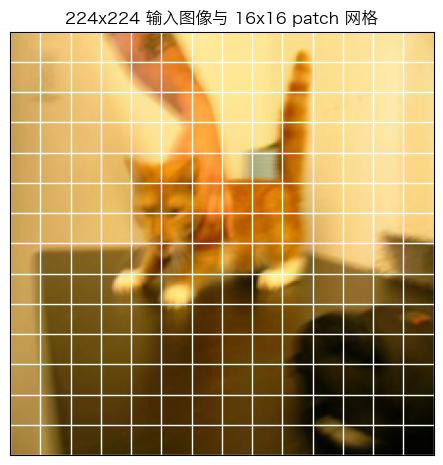

单张图像形状: (3, 224, 224)
patch 数量: 196


In [4]:
def show_image_with_patch_grid(image, patch_size=16, title="224x224 输入图像与 16x16 patch 网格"):
    """显示形状为 (3, H, W) 的图像，并叠加 patch 边界。"""
    _, height, width = image.shape
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.imshow(image.permute(1, 2, 0).clamp(0, 1))
    for pos in range(0, height + 1, patch_size):
        ax.axhline(pos - 0.5, color="white", linewidth=1.0)
    for pos in range(0, width + 1, patch_size):
        ax.axvline(pos - 0.5, color="white", linewidth=1.0)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

show_image_with_patch_grid(demo_image, patch_size=patch_size)
print("单张图像形状:", tuple(demo_image.shape))
print("patch 数量:", (image_size // patch_size) * (image_size // patch_size))

可视化中每个小方格就是一个 patch。对 `224 x 224` 图像使用 `16 x 16` patch，会得到 `14 x 14 = 196` 个 patch。



这些 patch 的排列顺序通常按从上到下、从左到右展开。展开后，二维图像结构会变成一维 token 序列，因此 ViT 需要额外的位置编码告诉模型“这个 token 原来在图像的哪个位置”。

In [5]:
class PatchEmbedding(nn.Module):
    """
    将图像切成 patch，并把每个 patch 投影为 D 维 token。

    Args:
        image_size: 输入图像边长，教学版本假设 H = W = image_size。
        patch_size: patch 边长 P。
        in_channels: 输入通道数 C，RGB 图像为 3。
        embed_dim: token 维度 D。

    Input:
        x: 图像张量，形状为 (B, C, H, W)。

    Output:
        tokens: patch token，形状为 (B, N, D)，其中 N = (H/P) * (W/P)。
    """

    def __init__(self, image_size=224, patch_size=16, in_channels=3, embed_dim=64):
        super().__init__()
        assert image_size % patch_size == 0, "image_size 必须能被 patch_size 整除"
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)  # (B, D, H/P, W/P)
        x = x.flatten(2)  # (B, D, N)，其中 N = (H/P) * (W/P)
        x = x.transpose(1, 2)  # (B, N, D)
        return x

patch_embed = PatchEmbedding(image_size=image_size, patch_size=patch_size, in_channels=3, embed_dim=64)
batch = demo_image.unsqueeze(0).repeat(2, 1, 1, 1)
tokens = patch_embed(batch)
print("输入 batch 形状:", tuple(batch.shape))
print("patch token 形状:", tuple(tokens.shape))
print("num_patches:", patch_embed.num_patches)

输入 batch 形状: (2, 3, 224, 224)
patch token 形状: (2, 196, 64)
num_patches: 196


这里使用 `Conv2d` 实现 patch embedding。它和“先切块、拉平、再过线性层”是等价的：

- 卷积核大小 `kernel_size = P`，每个卷积核正好覆盖一个 patch。
- 步幅 `stride = P`，相邻卷积窗口不重叠。
- 输出通道数 `embed_dim = D`，对应每个 patch 的 embedding 维度。

这种写法在工程中更简洁，但理解时仍可以把它看成 `N` 个 patch 共用同一个线性投影。

<details>
<summary>思考题：如果 patch_size 变大，token 数量和模型观察细节的能力会怎样变化？</summary>

`patch_size` 变大时，token 数量 `N` 会变少，自注意力计算更便宜；但每个 token 覆盖的图像区域更大，模型更难直接看到细粒度局部结构。`patch_size` 变小时，细节更多，但注意力矩阵更大，计算开销更高。
</details>

### 模型组件：[CLS] token 和位置编码

ViT 用 Transformer Encoder 处理 patch token。分类任务需要输出一张图的类别，而不是每个 patch 的类别。

常见做法是在 patch token 前面加入一个可学习的 `[CLS]` token：

$$
(B, N, D) \rightarrow (B, N+1, D)
$$

经过多层自注意力后，`[CLS]` token 会聚合其他 patch 的信息。最后只取 `[CLS]` 对应位置的向量做分类。

因为自注意力本身不关心 token 的顺序，所以还需要加入位置编码：

$$
\text{tokens} = \text{patch\_tokens} + \text{position\_embedding}
$$

在 ViT 中，位置编码通常是可学习参数，形状为 `(1, N+1, D)`。

In [6]:
class TokenPreparation(nn.Module):
    """
    加入 [CLS] token 和可学习位置编码。

    Input:
        patch_tokens: 形状为 (B, N, D)。

    Output:
        tokens: 形状为 (B, N+1, D)。第 0 个 token 是 [CLS]。
    """

    def __init__(self, num_patches, embed_dim, dropout=0.0):
        super().__init__()
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, patch_tokens):
        batch_size = patch_tokens.shape[0]
        cls_tokens = self.cls_token.expand(batch_size, -1, -1) # (B, 1, D)
        tokens = torch.cat([cls_tokens, patch_tokens], dim=1) # (B, N+1, D)
        tokens = tokens + self.pos_embed # (B, N+1, D)
        return self.dropout(tokens) # (B, N+1, D)

token_prep = TokenPreparation(num_patches=patch_embed.num_patches, embed_dim=64)
tokens_with_cls = token_prep(tokens)
print("patch token 形状:", tuple(tokens.shape))
print("加入 [CLS] 后形状:", tuple(tokens_with_cls.shape))
print("位置编码形状:", tuple(token_prep.pos_embed.shape))

patch token 形状: (2, 196, 64)
加入 [CLS] 后形状: (2, 197, 64)
位置编码形状: (1, 197, 64)


### 模型组件：多头自注意力

自注意力的输入和输出形状都保持为 `(B, L, D)`，其中 `L = N + 1`，包含 `[CLS]` token 和所有 patch token。

在一个注意力头中，模型先把输入投影为：

$$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V
$$

然后计算注意力权重：

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_h}}\right)V
$$

其中 `d_h = D / num_heads`。多头注意力会把 `D` 维拆成多个头：

$$
(B, L, D) \rightarrow (B, H, L, d_h)
$$

注意力矩阵的形状是 `(B, H, L, L)`。对于图像分类，它表示“每个 token 在每个头里关注其他 token 的程度”。

In [7]:
def attention(query, key, value, mask=None, dropout=None):
    """
    计算缩放点积注意力。

    Args:
        query: 查询张量，形状为 (B, H, Lq, Dh)。
        key: 键张量，形状为 (B, H, Lk, Dh)。
        value: 值张量，形状为 (B, H, Lk, Dh)。
        mask: 可选掩码。
            编码器自注意力中形状通常为 (B, 1, 1, S)。
            解码器源目标注意力中形状通常为 (B, 1, 1, S)。
            解码器自注意力中形状通常为 (B, 1, T, T)。
        dropout: 可选 dropout 模块。

    Returns:
        output: 注意力输出，形状为 (B, H, Lq, Dh)。
        p_attn: 注意力权重，形状为 (B, H, Lq, Lk)。
    """
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k) # (B, H, Lq, Lk)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    p_attn = scores.softmax(dim=-1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    out = torch.matmul(p_attn, value) # (B, H, Lq, Dh)
    return out, p_attn


class MultiHeadSelfAttention(nn.Module):
    """
    多头注意力模块。
    Args:
        h: 注意力头数 H。
        d_model: 模型隐藏维度 D。
        dropout: dropout 比例。
    """

    def __init__(self, h, d_model, dropout=0.1):
        super(MultiHeadSelfAttention, self).__init__()
        assert d_model % h == 0
        self.d_k = d_model // h
        self.h = h
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x, mask=None):
        """
        Args:
            x: 输入张量，形状为 (B, L, D)。
            mask: 可选掩码。
        Returns:
            多头拼接并线性映射后的结果，形状为 (B, L, D)。
            同时返回注意力权重，形状为 (B, H, L, L)。
        """
        if mask is not None:
            mask = mask.unsqueeze(1)
        batch_size = x.size(0)

        query = self.w_q(x).view(batch_size, -1, self.h, self.d_k).transpose(1, 2) # (B, L, D) -> (B, L, H, d_k) -> (B, H, L, d_k)
        key = self.w_k(x).view(batch_size, -1, self.h, self.d_k).transpose(1, 2) # (B, L, D) -> (B, L, H, d_k) -> (B, H, L, d_k)
        value = self.w_v(x).view(batch_size, -1, self.h, self.d_k).transpose(1, 2) # (B, L, D) -> (B, L, H, d_k) -> (B, H, L, d_k)

        x, self.attn = attention(
            query, key, value, mask=mask, dropout=self.dropout
        ) # (B, H, Lq, d_k), (B, H, Lq, Lk)

        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_k)
        return self.w_o(x), self.attn

### 模型组件：Transformer Encoder Block

ViT 使用的是 Transformer Encoder，而不是原始机器翻译 Transformer 中的 encoder-decoder 结构。

一个 Encoder Block 通常包含两部分：

1. 多头自注意力：让每个 token 与其他 token 交换信息。
2. MLP：对每个 token 的表示做非线性变换。

配合 LayerNorm 和残差连接后，结构可以写成：

$$
X' = X + \mathrm{MSA}(\mathrm{LN}(X))
$$

$$
Y = X' + \mathrm{MLP}(\mathrm{LN}(X'))
$$

输入输出形状保持不变：

$$
(B, L, D) \rightarrow (B, L, D)
$$

In [8]:
class MLP(nn.Module):
    """
    Transformer Encoder 中的前馈网络。

    Input/Output:
        输入和输出都为 (B, L, D)。中间隐藏层通常扩展到 mlp_ratio * D。
    """

    def __init__(self, embed_dim=64, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class TransformerEncoderBlock(nn.Module):
    """
    ViT 使用的 Transformer Encoder Block。

    Input:
        x: 形状为 (B, L, D)。

    Output:
        x: 形状仍为 (B, L, D)。
    """

    def __init__(self, embed_dim=64, num_heads=4, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(h=num_heads, d_model=embed_dim, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x, return_attention=False):
        attn_out, attn = self.attn(self.norm1(x)) # attn_out: (B, L, D), attn: (B, H, L, L)
        x = x + attn_out # (B, L, D)
        x = x + self.mlp(self.norm2(x)) # (B, L, D)

        if return_attention:
            return x, attn
        return x

block = TransformerEncoderBlock(embed_dim=64, num_heads=4, mlp_ratio=2.0)
block_out, block_attn = block(tokens_with_cls, return_attention=True)
print("Encoder Block 输入:", tuple(tokens_with_cls.shape))
print("Encoder Block 输出:", tuple(block_out.shape))
print("Block 内注意力形状:", tuple(block_attn.shape))

Encoder Block 输入: (2, 197, 64)
Encoder Block 输出: (2, 197, 64)
Block 内注意力形状: (2, 4, 197, 197)


残差连接的作用是让模块学习“在原表示上补充什么”，而不是每层都重新生成完整表示。LayerNorm 则帮助稳定训练。

这里采用的是 ViT 常见的 Pre-LN 形式：先归一化，再进入注意力或 MLP。它在深层 Transformer 中通常更稳定。

### 把组件拼起来：完整 Vision Transformer

前面已经分别解释了 patch embedding、[CLS] token、位置编码和 Transformer Encoder Block。
现在把这些模块重新组合起来，就得到一个完整的 Vision Transformer 分类器。

完整前向传播路径如下：

$$
(B, C, H, W)
\xrightarrow{PatchEmbedding}
(B, N, D)
\xrightarrow{Add\ [CLS]\ and\ Position}
(B, N+1, D)
\xrightarrow{Encoder\ Blocks}
(B, N+1, D)
\xrightarrow{Take\ [CLS]}
(B, D)
\xrightarrow{Linear}
(B, num\_classes)
$$

分类头输出的是 logits，形状为 `(B, num_classes)`。训练时通常使用交叉熵损失 `CrossEntropyLoss`。

In [9]:
@dataclass
class ViTConfig:
    """教学版 ViT 的配置。"""
    image_size: int = 224
    patch_size: int = 16
    in_channels: int = 3
    num_classes: int = 2
    embed_dim: int = 64
    depth: int = 2
    num_heads: int = 4
    mlp_ratio: float = 2.0
    dropout: float = 0.0

class VisionTransformer(nn.Module):
    """
    最小可运行 Vision Transformer。

    Input:
        x: 图像张量，形状为 (B, C, H, W)。

    Output:
        logits: 分类 logits，形状为 (B, num_classes)。
    """

    def __init__(self, config: ViTConfig):
        super().__init__()
        self.config = config
        self.patch_embed = PatchEmbedding(
            image_size=config.image_size,
            patch_size=config.patch_size,
            in_channels=config.in_channels,
            embed_dim=config.embed_dim,
        )
        self.token_prep = TokenPreparation(
            num_patches=self.patch_embed.num_patches,
            embed_dim=config.embed_dim,
            dropout=config.dropout,
        )
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=config.embed_dim,
                num_heads=config.num_heads,
                mlp_ratio=config.mlp_ratio,
                dropout=config.dropout,
            )
            for _ in range(config.depth)
        ])
        self.norm = nn.LayerNorm(config.embed_dim)
        self.head = nn.Linear(config.embed_dim, config.num_classes)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    def forward_features(self, x, return_last_attention=False):
        x = self.patch_embed(x) # (B, N, D)
        x = self.token_prep(x) # (B, N+1, D)

        last_attention = None
        for index, block in enumerate(self.blocks):
            want_attention = return_last_attention and index == len(self.blocks) - 1
            if want_attention:
                x, last_attention = block(x, return_attention=True) # x: (B, N+1, D)
            else:
                x = block(x) # (B, N+1, D)

        x = self.norm(x) # (B, N+1, D)
        cls_feature = x[:, 0] # (B, D)
        if return_last_attention:
            return cls_feature, last_attention
        return cls_feature

    def forward(self, x):
        cls_feature = self.forward_features(x) # (B, D)
        logits = self.head(cls_feature) # (B, num_classes)
        return logits

config = ViTConfig(image_size=image_size, patch_size=patch_size)
model = VisionTransformer(config).to(device)
dummy_images = torch.randn(4, 3, config.image_size, config.image_size, device=device)
logits = model(dummy_images)
features, last_attn = model.forward_features(dummy_images, return_last_attention=True)
print("输入图像:", tuple(dummy_images.shape))
print("[CLS] 特征:", tuple(features.shape))
print("分类 logits:", tuple(logits.shape))
print("最后一层注意力:", tuple(last_attn.shape))

输入图像: (4, 3, 224, 224)
[CLS] 特征: (4, 64)
分类 logits: (4, 2)
最后一层注意力: (4, 4, 197, 197)


## 5. 数据集与任务定义

为了让数据处理保持简单，同时又使用真实图像，这里直接使用整理好的 cats_dogs_light 全量数据集。
读取时只做两件事：从 train 和 val 目录加载猫狗图像，并统一缩放到 224 x 224；之后训练阶段直接把 ImageFolder 交给 PyTorch 的 DataLoader。

任务定义：

- 类别 `0`：猫（cats）。

- 类别 `1`：狗（dogs）。

这个实验的目标不是追求高精度，而是验证 ViT 的完整训练路径已经能在真实图像上跑通：输入图像、前向传播、交叉熵损失、反向传播和参数更新。

输入输出关系：

- 输入 `images`: `(B, 3, 224, 224)`。

- 标签 `labels`: `(B,)`，取值为 `0` 或 `1`。

- 输出 `logits`: `(B, 2)`。

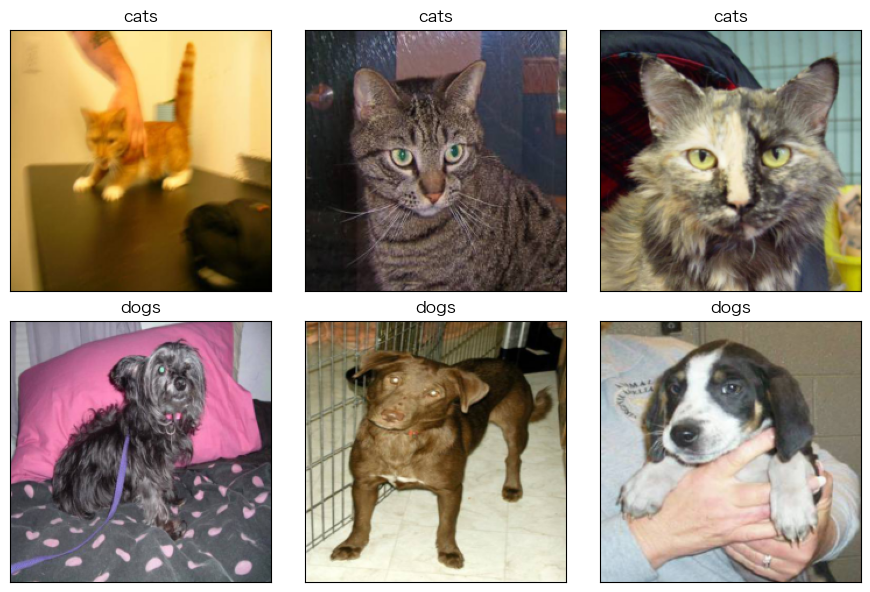

训练集样本数: 1000
验证集样本数: 400
单个 batch 图像形状: (32, 3, 224, 224)
单个 batch 标签形状: (32,)


In [10]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
preview_images, preview_labels = next(iter(train_loader))

indices_by_class = {0: [], 1: []}
for idx, (_, class_idx) in enumerate(train_dataset.samples):
    if class_idx in indices_by_class and len(indices_by_class[class_idx]) < 3:
        indices_by_class[class_idx].append(idx)
    if all(len(v) == 3 for v in indices_by_class.values()):
        break

if not all(len(v) == 3 for v in indices_by_class.values()):
    raise ValueError("训练集中某个类别样本不足 3 张，无法完成 2x3 可视化。")

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for row, class_idx in enumerate([0, 1]):
    for col, sample_idx in enumerate(indices_by_class[class_idx]):
        image, label = train_dataset[sample_idx]
        ax = axes[row, col]
        ax.imshow(image.permute(1, 2, 0).clamp(0, 1))
        ax.set_title(class_names[label])
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

print("训练集样本数:", len(train_dataset))
print("验证集样本数:", len(val_dataset))
print("单个 batch 图像形状:", tuple(preview_images.shape))
print("单个 batch 标签形状:", tuple(preview_labels.shape))

## 6. 损失函数定义

这是一个二分类任务，但模型输出的不是单个概率，而是形状为 `(B, 2)` 的 logits。
因此这里直接使用交叉熵损失 `F.cross_entropy`，它会在内部完成 softmax 和负对数似然计算。

如果某个 batch 的标签形状为 `(B,)`，模型输出形状为 `(B, 2)`，那么交叉熵会衡量“模型给真实类别分配的分数是否足够高”。

## 7. 模型训练过程

训练阶段我们仍然保持教学简化：

- 直接使用 PyTorch 的 `DataLoader` 提供 batch。
- 使用一个很小的 ViT 配置，确保 notebook 能快速运行。
- 每个 epoch 结束后，只记录训练损失和验证准确率。

这样做的重点不是追求最好结果，而是让读者清楚看到模型、损失函数和参数更新是如何串起来的。

In [11]:
def accuracy(model, data_loader):
    """使用 DataLoader 计算分类准确率。"""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)
            logits = model(batch_images)
            pred = logits.argmax(dim=1)
            correct += (pred == batch_labels).sum().item()
            total += batch_labels.numel()
    return correct / total


def train_one_small_vit(
    model,
    train_loader,
    val_loader,
    epochs=30,
    base_lr=3e-4,
    weight_decay=0.05,
    warmup_epochs=5,
    min_lr_ratio=0.05,
    patience=5,
    min_delta=1e-4,
):
    """轻量训练循环：AdamW + warmup/cosine 调度 + 早停。"""
    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)

    warmup_epochs = max(1, min(warmup_epochs, epochs))
    cosine_epochs = max(1, epochs - warmup_epochs)
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[
            torch.optim.lr_scheduler.LinearLR(
                optimizer,
                start_factor=1.0 / warmup_epochs,
                end_factor=1.0,
                total_iters=warmup_epochs,
            ),
            torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer,
                T_max=cosine_epochs,
                eta_min=base_lr * min_lr_ratio,
            ),
        ],
        milestones=[warmup_epochs],
    )

    history = []
    best_val_acc = -float("inf")
    best_state = None
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_samples = 0

        for batch_images, batch_labels in train_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)
            logits = model(batch_images)
            loss = F.cross_entropy(logits, batch_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = batch_labels.numel()
            total_loss += loss.item() * batch_size
            total_samples += batch_size

        avg_loss = total_loss / total_samples
        val_acc = accuracy(model, val_loader)
        current_lr = optimizer.param_groups[0]["lr"]
        history.append((avg_loss, val_acc))

        print(f"epoch {epoch:03d} | lr={current_lr:.6f} | loss={avg_loss:.4f} | val_acc={val_acc:.3f}")

        if val_acc > best_val_acc + min_delta:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"触发早停：连续 {patience} 个 epoch 验证准确率无明显提升。")
                break

        scheduler.step()

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"恢复最佳模型参数，best_val_acc={best_val_acc:.3f}")

    return history


set_seed(7)
small_config = ViTConfig(
    image_size=image_size,
    patch_size=patch_size,
    embed_dim=64,
    depth=2,
    num_heads=4,
    mlp_ratio=2.0,
    dropout=0.0,
)
small_model = VisionTransformer(small_config).to(device)
history = train_one_small_vit(small_model, train_loader, val_loader, epochs=30)

epoch 001 | lr=0.000060 | loss=0.6900 | val_acc=0.560
epoch 002 | lr=0.000108 | loss=0.6886 | val_acc=0.497
epoch 003 | lr=0.000156 | loss=0.6939 | val_acc=0.520
epoch 004 | lr=0.000204 | loss=0.6895 | val_acc=0.500
epoch 005 | lr=0.000252 | loss=0.6873 | val_acc=0.580
epoch 006 | lr=0.000300 | loss=0.6874 | val_acc=0.557
epoch 007 | lr=0.000299 | loss=0.6804 | val_acc=0.545
epoch 008 | lr=0.000296 | loss=0.6719 | val_acc=0.595
epoch 009 | lr=0.000290 | loss=0.6825 | val_acc=0.550
epoch 010 | lr=0.000282 | loss=0.6719 | val_acc=0.573
epoch 011 | lr=0.000273 | loss=0.6639 | val_acc=0.620
epoch 012 | lr=0.000261 | loss=0.6504 | val_acc=0.583
epoch 013 | lr=0.000248 | loss=0.6459 | val_acc=0.608
epoch 014 | lr=0.000234 | loss=0.6380 | val_acc=0.618
epoch 015 | lr=0.000218 | loss=0.6176 | val_acc=0.578
epoch 016 | lr=0.000202 | loss=0.6052 | val_acc=0.610
触发早停：连续 5 个 epoch 验证准确率无明显提升。
恢复最佳模型参数，best_val_acc=0.620


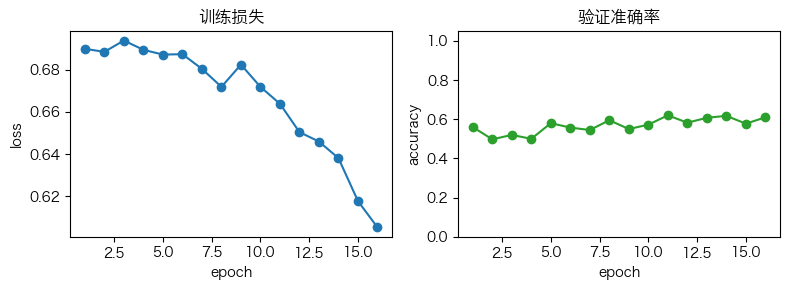

In [12]:
losses = [item[0] for item in history]
accs = [item[1] for item in history]
epochs = range(1, len(history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(epochs, losses, marker="o")
axes[0].set_title("训练损失")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")

axes[1].plot(epochs, accs, marker="o", color="tab:green")
axes[1].set_title("验证准确率")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 8. 最小可运行示例与结果解释

上面的损失曲线和验证准确率，就是这个 notebook 的最小可运行示例。
它说明当前 ViT 实现已经具备完整训练闭环：数据进入模型后，可以完成前向传播、交叉熵损失计算、反向传播和参数更新。

这里的结果不应被当作最终性能评估，原因有三点：

- 模型规模很小，只用于教学。
- 训练 epoch 很少，主要是为了快速验证。
- 没有加入更复杂的数据增强、正则化和训练技巧。

因此，这一节更重要的结论不是“准确率有多高”，而是“模型主路径已经跑通，且输出与任务定义一致”。

In [13]:
def show_cls_attention(attn, image, image_size=224, patch_size=16):
    """
    可视化 [CLS] token 对各个 patch 的注意力。

    Args:
        attn: 注意力权重，形状为 (B, H, L, L)。
        image: 原始图像张量，形状为 (3, H, W)。
        image_size: 原图边长。
        patch_size: patch 边长。

    Returns:
        H 行 2 列的注意力可视化图：左列为单独注意力图，右列为与原图叠加的热力图。
    """
    num_patches_per_side = image_size // patch_size
    image = image.detach().cpu().permute(1, 2, 0).clamp(0, 1)
    num_heads = attn.shape[1]

    fig, axes = plt.subplots(num_heads, 2, figsize=(9, 2.4 * num_heads))
    if num_heads == 1:
        axes = np.expand_dims(axes, axis=0)

    for head in range(num_heads):
        cls_to_patches = attn[0, head, 0, 1:]
        attention_map = cls_to_patches.reshape(num_patches_per_side, num_patches_per_side).detach().cpu()
        attention_image = attention_map.repeat_interleave(patch_size, dim=0).repeat_interleave(patch_size, dim=1)

        left_ax = axes[head, 0]
        left_im = left_ax.imshow(attention_map, cmap="viridis")
        left_ax.set_title(f"head {head} | attention")
        left_ax.set_xticks([])
        left_ax.set_yticks([])
        fig.colorbar(left_im, ax=left_ax, fraction=0.046, pad=0.04)

        right_ax = axes[head, 1]
        right_ax.imshow(image)
        right_ax.imshow(attention_image, cmap="viridis", alpha=0.45)
        right_ax.set_title(f"head {head} | attention + image")
        right_ax.set_xticks([])
        right_ax.set_yticks([])

    plt.tight_layout()
    plt.show()


这组图按 `H` 行 2 列展示每个注意力头的 `[CLS]` 到 patch 的关注情况。左列是单独的注意力图，右列是把注意力热力图叠加到原图上的结果。由于模型已经训练过，图中可能会出现一定的空间偏好，但它仍然只适合做辅助观察。它的教学价值在于说明：

- `[CLS]` 可以直接和所有 patch 交互。
- 每个注意力头都有一张自己的 `L x L` 注意力矩阵。
- 训练后，不同头可能学习到不同的空间关注模式。

<details>
<summary>思考题：注意力图亮的位置一定等于模型“真正依据”的位置吗？</summary>

不一定。注意力权重能提供一种观察模型信息流的方式，但它不是严格的因果解释。模型输出还受到 value 投影、后续 MLP、残差连接和多层叠加的影响。因此注意力图适合辅助理解，但不能直接等同于完整解释。
</details>

### 结果补充：观察训练后的注意力

最后，我们选取一张验证图像，查看模型最后一层中 `[CLS]` token 对各个 patch 的注意力分布。这个可视化的主要作用是帮助理解信息流动路径，而不是提供严格的因果解释。

另外需要说明的是：本教程使用的是从零开始训练的教学版小模型，且训练数据规模有限，因此注意力热力图可能不够稳定或不够“聚焦”。这属于预期现象，不影响我们对 ViT 机制本身的理解。

样例索引: 26
真实标签: cats
预测类别: cats


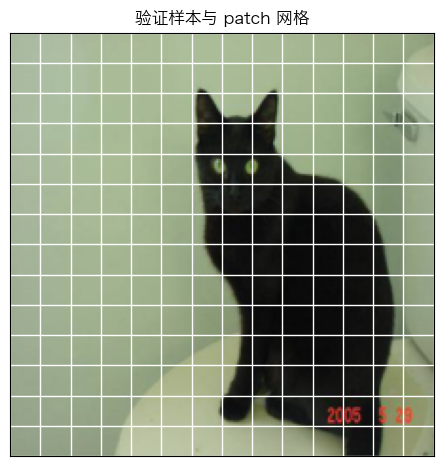

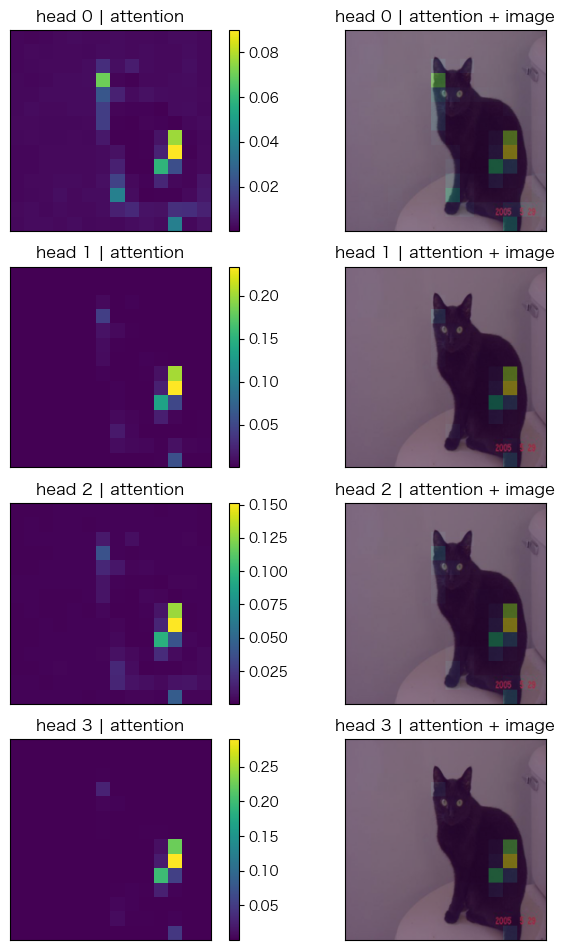

In [20]:
small_model.eval()
sample_idx = 26  # 修改这里可以查看验证集中的其他样例
example_image, example_label = val_dataset[sample_idx]
example = example_image.unsqueeze(0).to(device)

with torch.no_grad():
    logits = small_model(example)
    pred = logits.argmax(dim=1).item()
    _, trained_attn = small_model.forward_features(example, return_last_attention=True)

print("样例索引:", sample_idx)
print("真实标签:", class_names[example_label])
print("预测类别:", class_names[pred])
show_image_with_patch_grid(example_image.cpu(), patch_size=patch_size, title="验证样本与 patch 网格")
show_cls_attention(trained_attn.cpu(), example_image.cpu(), image_size=image_size, patch_size=patch_size)

### 使用预训练模型可视化

最后，我们在同一张验证样本上，再看一遍预训练 ViT-B/16 的最后一层 `[CLS] -> patch` 注意力图。
这样做的目的不是比较“谁更准确”，而是帮助理解：当模型在大规模数据上预训练后，注意力分布通常会更稳定，也更容易出现与目标区域相关的空间模式。

阅读这组图时可以重点观察三点：

1. 不同注意力头是否仍然呈现差异化分工（有的关注轮廓，有的关注局部纹理）。
2. 与前面教学小模型相比，热力图是否更连贯、噪声更少。
3. 高响应区域是否更多落在猫的头部、躯干等语义相关位置。

需要强调的是：注意力图是“信息交互强度”的可视化，不应直接等同于严格因果解释。
它更适合用于教学观察和模型行为分析，而不是单独作为可解释性结论。

预训练模型预测: Egyptian cat


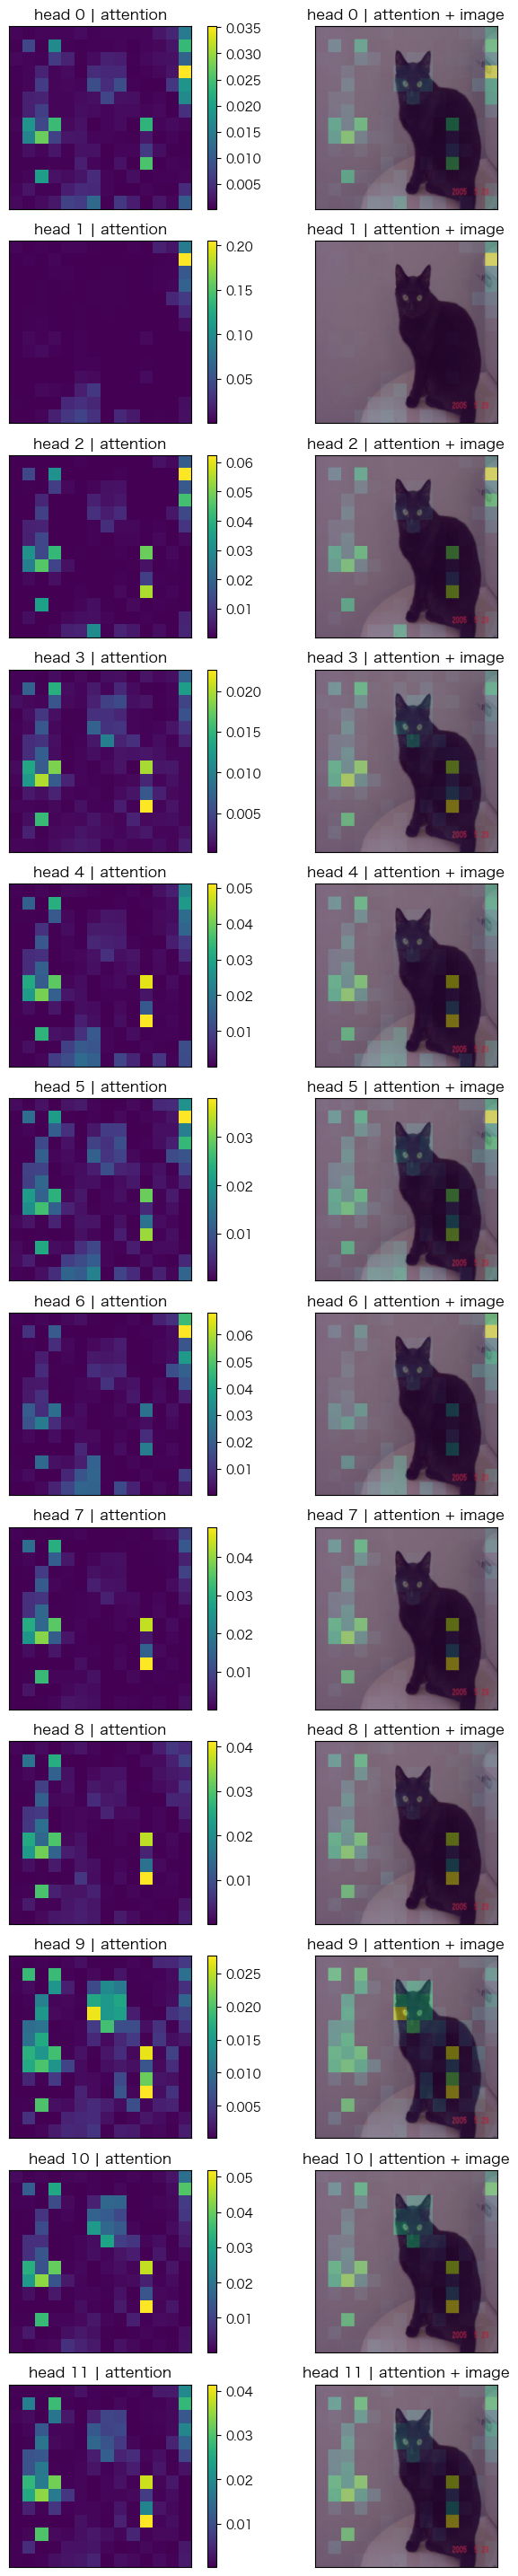

In [21]:
from torchvision.models import ViT_B_16_Weights, vit_b_16

weights = ViT_B_16_Weights.DEFAULT
pretrained_vit = vit_b_16(weights=weights).to(device).eval()
x = weights.transforms()(example_image).unsqueeze(0).to(device)

cache = {}
orig_forward = pretrained_vit.encoder.layers[-1].self_attention.forward

def forward_with_weights(*args, **kwargs):
    kwargs["need_weights"] = True
    kwargs["average_attn_weights"] = False
    return orig_forward(*args, **kwargs)

def save_attn(_module, _inputs, output):
    cache["attn"] = output[1].detach().cpu()

pretrained_vit.encoder.layers[-1].self_attention.forward = forward_with_weights
hook = pretrained_vit.encoder.layers[-1].self_attention.register_forward_hook(save_attn)

with torch.no_grad():
    logits = pretrained_vit(x)
hook.remove()
pretrained_vit.encoder.layers[-1].self_attention.forward = orig_forward

print("预训练模型预测:", weights.meta["categories"][logits.argmax(dim=1).item()])
show_cls_attention(cache["attn"], example_image.cpu(), image_size=image_size, patch_size=patch_size)

## 9. 小结

本节实现了一个教学版 Vision Transformer。核心形状变化可以概括为：

1. 图像输入：`(B, C, H, W)`，这里使用 `224 x 224` RGB 图像。

2. patch embedding：`(B, N, D)`，这里 `patch_size = 16`，所以 `N = (224/16)^2 = 196`。

3. 加入 `[CLS]` 和位置编码：`(B, N+1, D)`。

4. 多头自注意力：内部注意力矩阵为 `(B, H_heads, N+1, N+1)`，输出仍是 `(B, N+1, D)`。

5. 取 `[CLS]` 分类：`(B, D) -> (B, num_classes)`。

这次轻量验证直接使用了 `cats_dogs_light` 的全量训练集和验证集，并通过 PyTorch 的 `ImageFolder` 与 `DataLoader` 组织数据，因此 notebook 的数据处理保持得比较简单。

需要记住的局限性：

- 这里的模型是教学简化版，没有使用随机深度、复杂数据增强、预训练权重或大规模训练策略。

- 注意力可视化有助于理解 token 之间的信息流，但不能直接等同于模型解释。

- 这里虽然使用了全量数据，但仍然只训练了一个很小的模型和很少的 epoch；真实训练时通常需要更大的模型容量和更稳定的训练策略。

继续学习时，可以尝试把 `embed_dim`、`depth` 或 `num_heads` 调大，观察 token 数量不变时，模型容量和训练时间会如何变化。